# Mutual Fund Analytics - Exploratory Data Analysis

In [ ]:
# imports 
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.figure(figsize=(12,6))
sns.set_style("whitegrid")

<Figure size 1200x600 with 0 Axes>

In [ ]:
# load data
import os
import pandas as pd

print("Current Working Directory:")
print(os.getcwd())

print("\nChecking files...")

nav_path = "../data/processed/02_nav_history_clean.csv"
aum_path = "../data/raw/03_aum_by_fund_house.csv"
sip_path = "../data/raw/04_monthly_sip_inflows.csv"
category_path = "../data/raw/05_category_inflows.csv"
folios_path = "../data/raw/06_industry_folio_count.csv"
transactions_path = "../data/processed/08_investor_transactions_clean.csv"
performance_path = "../data/processed/07_scheme_performance_clean.csv"
portfolio_path = "../data/raw/09_portfolio_holdings.csv"

paths = [
    nav_path,
    aum_path,
    sip_path,
    category_path,
    folios_path,
    transactions_path,
    performance_path,
    portfolio_path
]

for path in paths:
    print(f"{path} --> {'FOUND' if os.path.exists(path) else 'NOT FOUND'}")

nav = pd.read_csv(nav_path)
aum = pd.read_csv(aum_path)
sip = pd.read_csv(sip_path)
category = pd.read_csv(category_path)
folios = pd.read_csv(folios_path)
transactions = pd.read_csv(transactions_path)
performance = pd.read_csv(performance_path)
portfolio = pd.read_csv(portfolio_path)

print("\nAll files loaded successfully!")

print("\nShapes:")
print("NAV:", nav.shape)
print("AUM:", aum.shape)
print("SIP:", sip.shape)
print("Category:", category.shape)
print("Folios:", folios.shape)
print("Transactions:", transactions.shape)
print("Performance:", performance.shape)
print("Portfolio:", portfolio.shape)

Current Working Directory:
c:\Users\suram\OneDrive\Desktop\MutualFundAnalytics\notebooks

Checking files...
../data/processed/02_nav_history_clean.csv --> FOUND
../data/raw/03_aum_by_fund_house.csv --> FOUND
../data/raw/04_monthly_sip_inflows.csv --> FOUND
../data/raw/05_category_inflows.csv --> FOUND
../data/raw/06_industry_folio_count.csv --> FOUND
../data/processed/08_investor_transactions_clean.csv --> FOUND
../data/processed/07_scheme_performance_clean.csv --> FOUND
../data/raw/09_portfolio_holdings.csv --> FOUND

All files loaded successfully!

Shapes:
NAV: (46000, 3)
AUM: (90, 5)
SIP: (48, 6)
Category: (144, 3)
Folios: (21, 6)
Transactions: (32778, 13)
Performance: (40, 19)
Portfolio: (322, 8)


In [ ]:
# Chart 1 — NAV Trend Analysis
nav["date"] = pd.to_datetime(nav["date"])

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend (2022-2026)"
)

fig.show()

In [12]:
fig.write_image("reports/nav_trend.png")

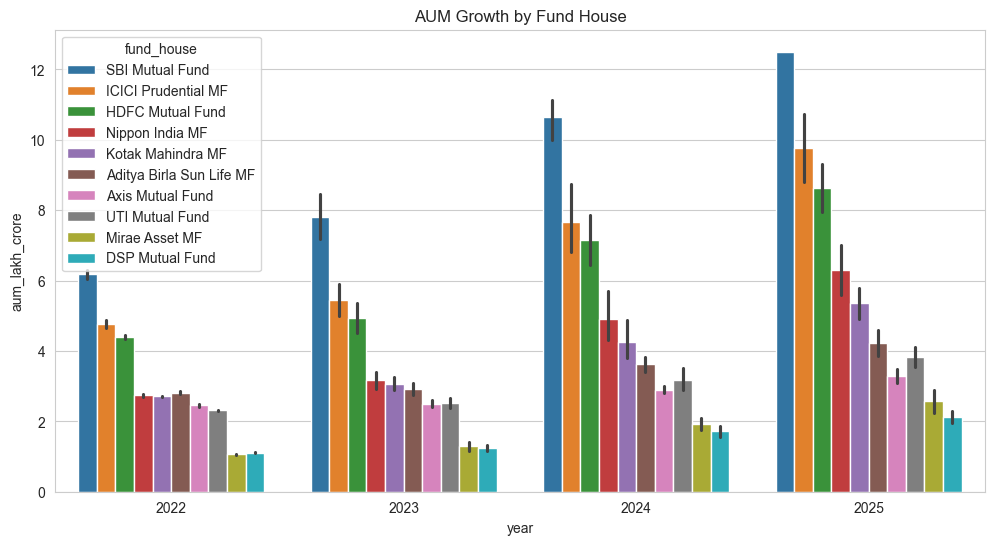

In [ ]:
# Chart 2 — AUM Growth
aum["year"] = pd.to_datetime(aum["date"]).dt.year

plt.figure(figsize=(12,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House")
plt.savefig("reports/aum_growth.png")
plt.show()

In [ ]:
# Chart 3 — SIP Inflow Trend
sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows"
)

fig.show()

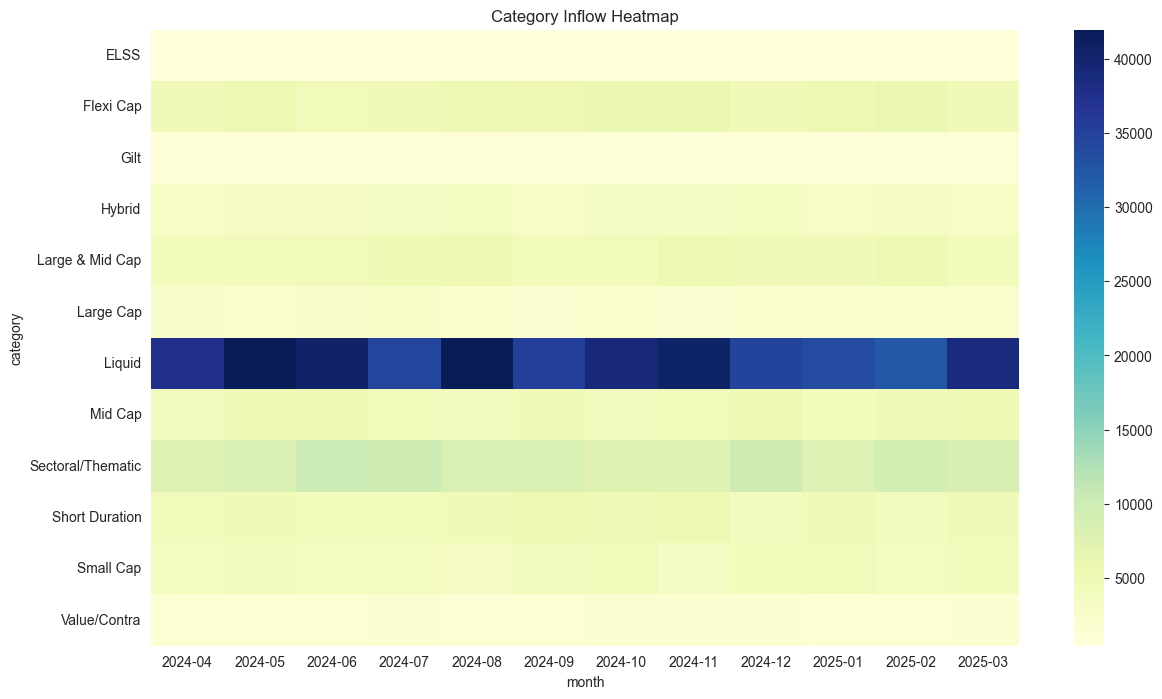

In [ ]:
# Chart 4 — Category Inflow Heatmap
pivot = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(14,8))

sns.heatmap(
    pivot,
    cmap="YlGnBu"
)

plt.title("Category Inflow Heatmap")

plt.savefig("reports/category_heatmap.png")
plt.show()

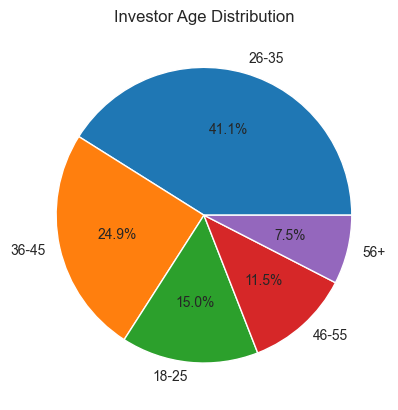

In [ ]:
# Chart 5 — Age Group Pie Chart
transactions["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Investor Age Distribution")

plt.savefig("reports/age_distribution.png")
plt.show()

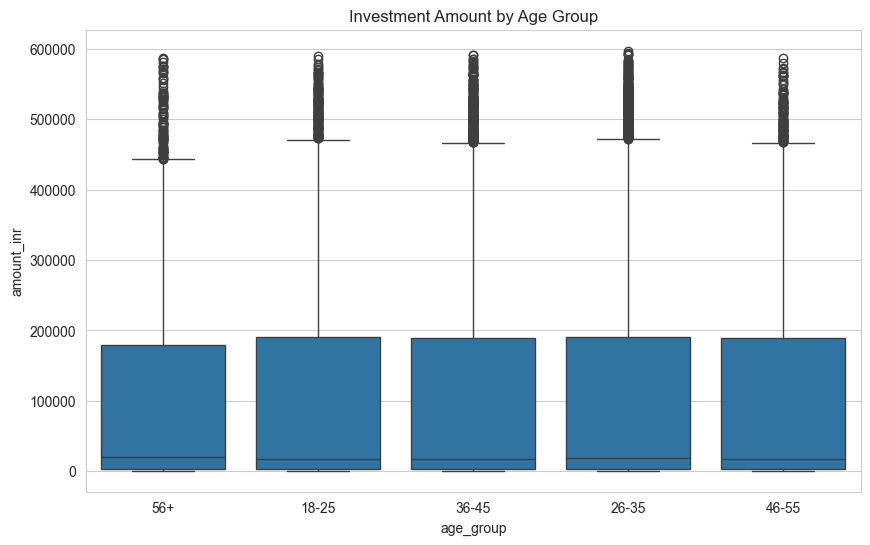

In [ ]:
# Chart 6 — SIP Amount by Age Group
plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount by Age Group")

plt.savefig("reports/age_boxplot.png")
plt.show()

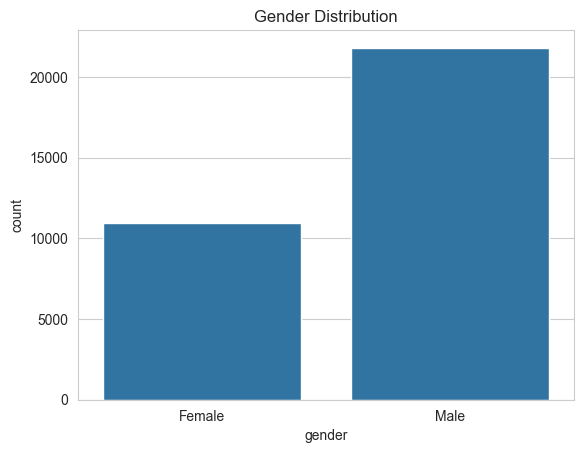

In [ ]:
# Chart 7 — Gender Split
sns.countplot(
    data=transactions,
    x="gender"
)

plt.title("Gender Distribution")

plt.savefig("reports/gender_split.png")
plt.show()

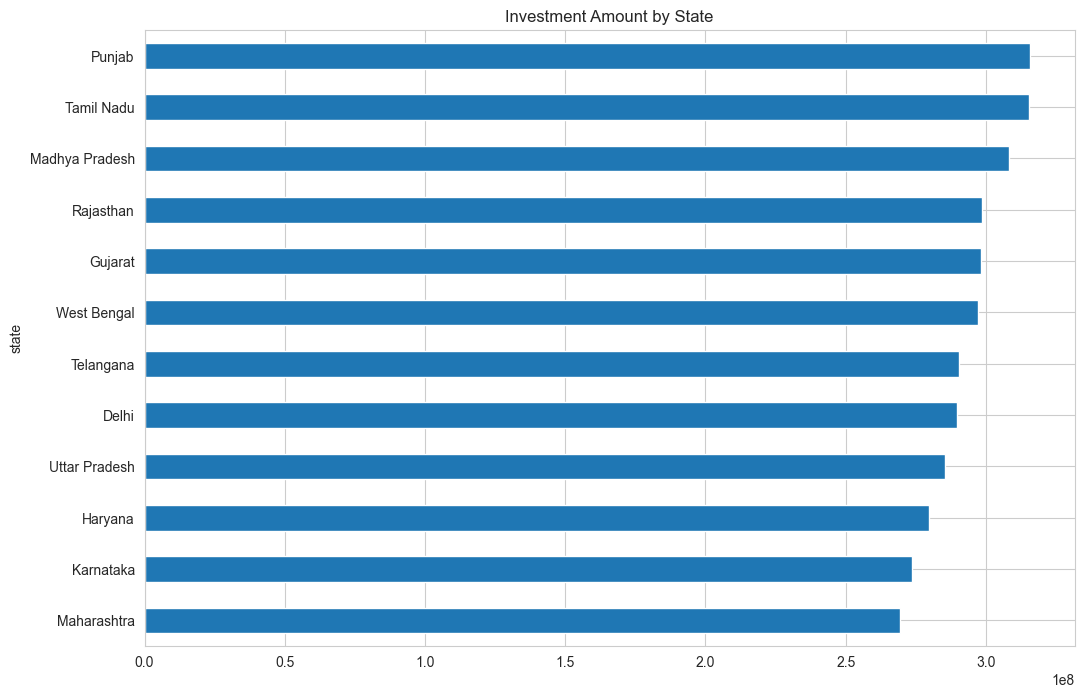

In [ ]:
# Chart 8 — SIP Amount by State
state_data = transactions.groupby(
    "state"
)["amount_inr"].sum().sort_values()

state_data.plot(
    kind="barh",
    figsize=(12,8)
)

plt.title("Investment Amount by State")

plt.savefig("reports/state_distribution.png")
plt.show()

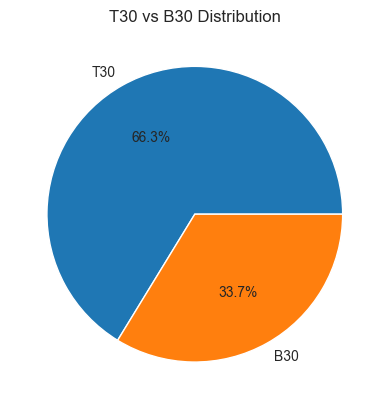

In [ ]:
# Chart 9 — T30 vs B30
transactions["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Distribution")

plt.savefig("reports/city_tier.png")
plt.show()

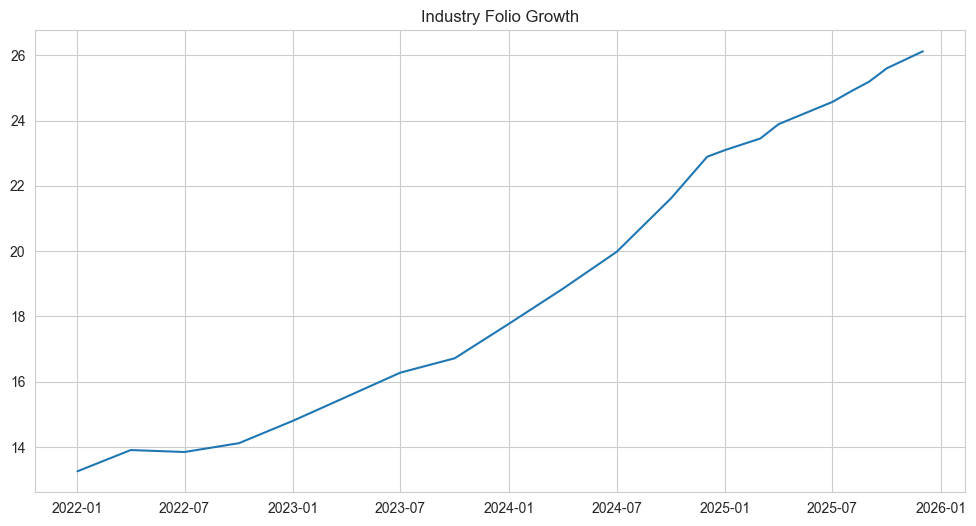

In [ ]:
#Chart 10 — Folio Growth
folios["month"] = pd.to_datetime(folios["month"])

plt.figure(figsize=(12,6))

plt.plot(
    folios["month"],
    folios["total_folios_crore"]
)

plt.title("Industry Folio Growth")

plt.savefig("reports/folio_growth.png")
plt.show()

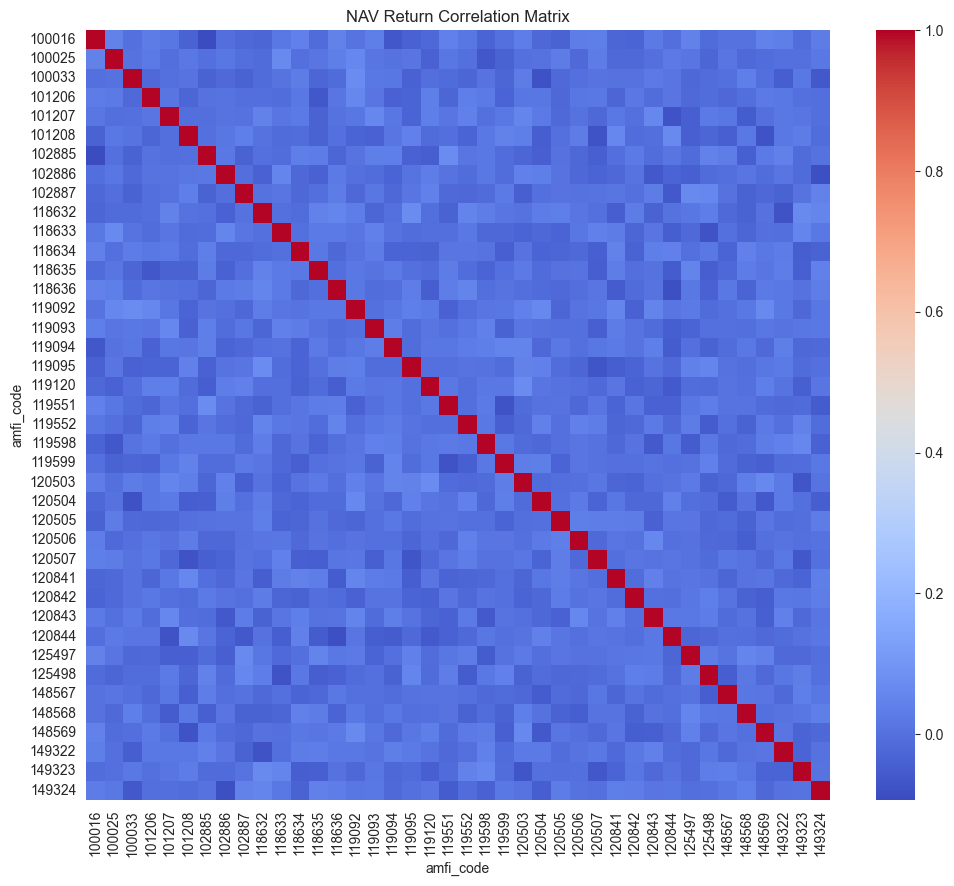

In [ ]:
# Chart 11 — Correlation Matrix
nav["date"] = pd.to_datetime(nav["date"])

pivot = nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = pivot.pct_change()

corr = returns.corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("NAV Return Correlation Matrix")

plt.savefig("reports/correlation_matrix.png")
plt.show()

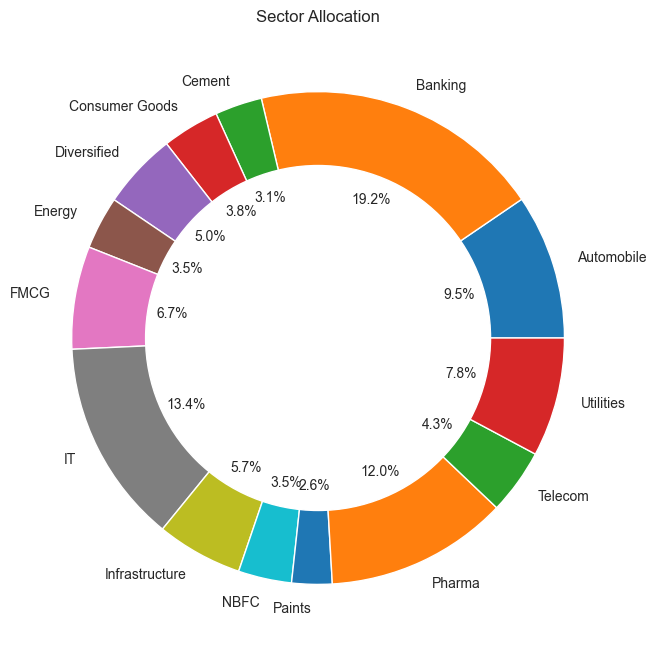

In [ ]:
#Chart 12 — Sector Allocation Donut
sector = portfolio.groupby(
    "sector"
)["weight_pct"].sum()

plt.figure(figsize=(8,8))

plt.pie(
    sector,
    labels=sector.index,
    autopct="%1.1f%%"
)

centre = plt.Circle((0,0),0.70,fc='white')

fig = plt.gcf()
fig.gca().add_artist(centre)

plt.title("Sector Allocation")

plt.savefig("reports/sector_allocation.png")
plt.show()

# Key EDA Findings

1. NAV values showed a consistent upward trend across most schemes between 2022 and 2026.

2. Equity-oriented schemes experienced stronger growth during the 2023 market rally.

3. Temporary corrections were visible during selected periods in 2024, followed by recovery.

4. SBI Mutual Fund maintained the highest AUM among major fund houses.

5. SIP inflows increased steadily throughout the study period.

6. December 2025 recorded the highest monthly SIP inflow in the dataset.

7. Younger and middle-aged investors contributed the majority of investment transactions.

8. T30 cities accounted for a larger share of investments compared to B30 cities.

9. Investor participation expanded significantly, with folio counts nearly doubling during the period.

10. Sector allocation remained diversified, with Financial Services, IT, and Large Cap sectors contributing major portfolio weights.

